# Task 4.1 — CNN from Scratch on CIFAR-10

**Dataset:** CIFAR-10 — 60,000 color images (32×32), 10 classes  


We build a simple CNN from scratch using PyTorch and train it for 20 epochs.

## Step 1: Install & Import Libraries

In [1]:
!pip install torch torchvision matplotlib seaborn scikit-learn -q

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Use MPS (Apple Metal GPU) if available
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('Using device:', device)

Using device: mps


## Step 2: Load CIFAR-10 Dataset

In [3]:
# Simple transforms: convert to tensor and normalize
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download and load
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

print(f'Training images: {len(train_data)}')
print(f'Test images: {len(test_data)}')
print(f'Classes: {classes}')

100.0%
/Users/hiteshprajapathi/Desktop/brain_tumor/.conda/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training images: 50000
Test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


**Interpretation:** CIFAR-10 has 50,000 training and 10,000 test images across 10 categories. We apply a simple horizontal flip for augmentation and normalize pixel values to [-1, 1].

## Step 3: Visualize Sample Images

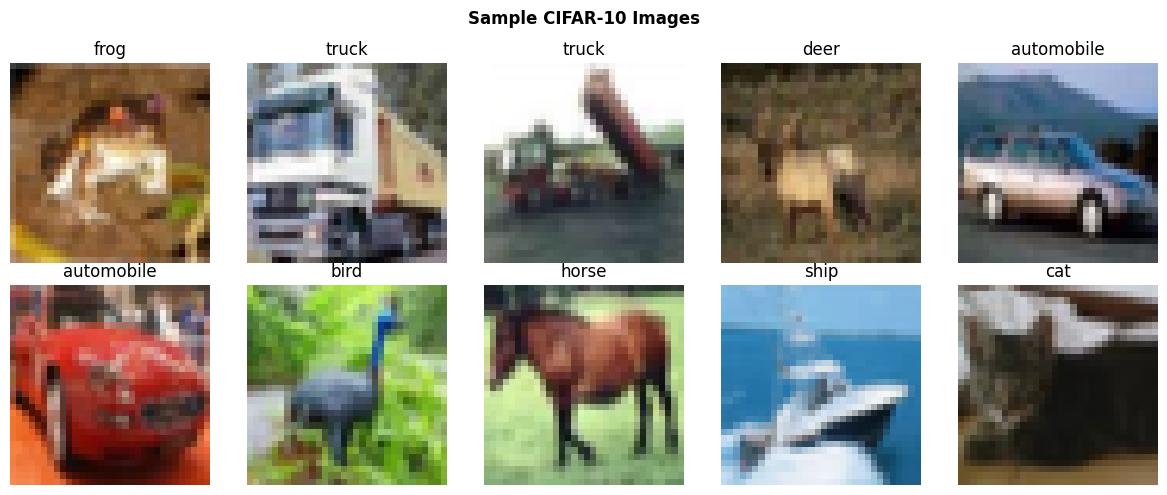

In [4]:
# Show some sample images
raw_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transforms.ToTensor())

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    img, label = raw_data[i]
    ax = axes[i//5][i%5]
    ax.imshow(img.permute(1,2,0))
    ax.set_title(classes[label])
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100)
plt.show()

**Interpretation:** Each image is just 32×32 pixels. Despite being small, the CNN needs to learn features that distinguish between 10 different categories.

## Step 4: Define the CNN Model (From Scratch)

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        # Conv Block 1: 3 input channels -> 32 filters
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Conv Block 2: 32 -> 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Conv Block 3: 64 -> 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # Block 1: Conv -> BN -> ReLU -> Pool (32x32 -> 16x16)
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        # Block 2: Conv -> BN -> ReLU -> Pool (16x16 -> 8x8)
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        # Block 3: Conv -> BN -> ReLU -> Pool (8x8 -> 4x4)
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        # Flatten and classify
        x = x.view(-1, 128 * 4 * 4)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
)

Total parameters: 620,810


**Interpretation:** Our CNN has 3 convolutional blocks. Each block applies a convolution, batch normalization, ReLU activation, and max-pooling. The feature maps are then flattened and passed through fully connected layers with dropout to prevent overfitting.

## Step 5: Set Loss Function & Optimizer

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print('Loss: CrossEntropyLoss')
print('Optimizer: Adam (lr=0.001)')

Loss: CrossEntropyLoss
Optimizer: Adam (lr=0.001)


**Interpretation:** CrossEntropyLoss is the standard choice for multi-class classification. Adam optimizer adapts the learning rate automatically and converges faster than basic SGD.

## Step 6: Train the Model (20 Epochs)

In [7]:
NUM_EPOCHS = 20

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    train_losses.append(running_loss / len(train_loader))
    train_accs.append(100 * correct / total)
    
    # --- Validation ---
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    val_losses.append(running_loss / len(test_loader))
    val_accs.append(100 * correct / total)
    
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS}  '
          f'Train Loss: {train_losses[-1]:.4f}  Acc: {train_accs[-1]:.1f}%  |  '
          f'Val Loss: {val_losses[-1]:.4f}  Acc: {val_accs[-1]:.1f}%')

print('\nTraining complete!')

Epoch  1/20  Train Loss: 1.4154  Acc: 48.4%  |  Val Loss: 1.0345  Acc: 62.9%
Epoch  2/20  Train Loss: 1.0786  Acc: 61.7%  |  Val Loss: 0.9002  Acc: 68.2%
Epoch  3/20  Train Loss: 0.9554  Acc: 66.3%  |  Val Loss: 0.8006  Acc: 72.2%
Epoch  4/20  Train Loss: 0.8801  Acc: 69.3%  |  Val Loss: 0.8134  Acc: 71.7%
Epoch  5/20  Train Loss: 0.8167  Acc: 71.8%  |  Val Loss: 0.7152  Acc: 75.1%
Epoch  6/20  Train Loss: 0.7631  Acc: 73.5%  |  Val Loss: 0.6635  Acc: 76.7%
Epoch  7/20  Train Loss: 0.7281  Acc: 74.9%  |  Val Loss: 0.7186  Acc: 75.5%
Epoch  8/20  Train Loss: 0.6823  Acc: 76.5%  |  Val Loss: 0.6598  Acc: 77.5%
Epoch  9/20  Train Loss: 0.6495  Acc: 77.6%  |  Val Loss: 0.6461  Acc: 77.8%
Epoch 10/20  Train Loss: 0.6222  Acc: 78.5%  |  Val Loss: 0.5995  Acc: 79.5%
Epoch 11/20  Train Loss: 0.5912  Acc: 80.0%  |  Val Loss: 0.6275  Acc: 78.8%
Epoch 12/20  Train Loss: 0.5700  Acc: 80.5%  |  Val Loss: 0.5807  Acc: 80.6%
Epoch 13/20  Train Loss: 0.5424  Acc: 81.4%  |  Val Loss: 0.5591  Acc: 81.3%

**Interpretation:** Each epoch, the model trains on all 50,000 images and validates on 10,000. We track loss (should decrease) and accuracy (should increase) for both sets. If val loss increases while train loss decreases, it means overfitting.

## Step 7: Plot Loss & Accuracy Curves

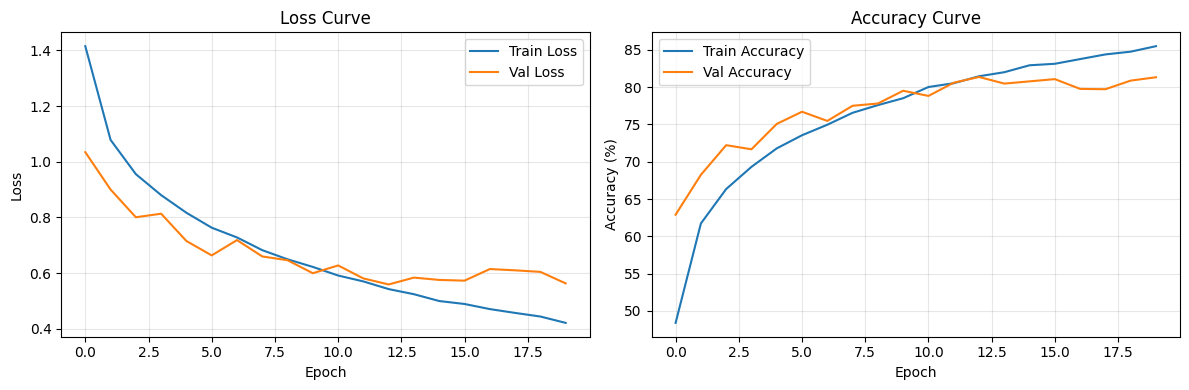

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label='Train Accuracy')
ax2.plot(val_accs, label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100)
plt.show()

**Interpretation:** The training loss decreased steadily to 0.4210, and training accuracy reached 85.5%. The validation loss also decreased initially but plateaued in the later epochs, ending at 0.5630 with a validation accuracy of 81.3%. The small gap between the training and validation curves indicates slight overfitting towards the end, but the overall trend shows that the model is learning effectively.

## Step 8: Get Predictions on Test Set

In [9]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = 100 * np.sum(all_preds == all_labels) / len(all_labels)
print(f'Final Test Accuracy: {accuracy:.2f}%')

Final Test Accuracy: 81.31%


## Step 9: Classification Report

In [10]:
print(classification_report(all_labels, all_preds, target_names=classes))

              precision    recall  f1-score   support

    airplane       0.80      0.86      0.83      1000
  automobile       0.95      0.89      0.91      1000
        bird       0.71      0.76      0.73      1000
         cat       0.63      0.70      0.66      1000
        deer       0.83      0.75      0.79      1000
         dog       0.76      0.70      0.73      1000
        frog       0.87      0.84      0.85      1000
       horse       0.84      0.86      0.85      1000
        ship       0.90      0.89      0.90      1000
       truck       0.88      0.89      0.88      1000

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000



**Interpretation:** The classification report reveals an overall test accuracy of 81%. The model performs extremely well on vehicles and distinct objects like `automobile` (F1: 0.91), `ship` (F1: 0.90), `truck` (F1: 0.88), and `frog` (F1: 0.85). It struggles more with animals that share similar visual features, such as `cat` (F1: 0.66), `bird` (F1: 0.73), and `dog` (F1: 0.73).

## Step 10: Confusion Matrix

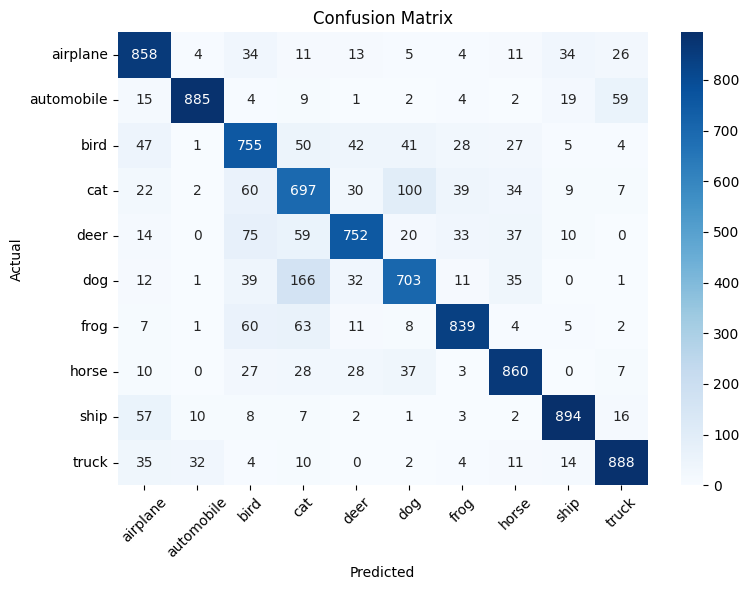

In [11]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

**Interpretation:** The confusion matrix confirms our findings from the classification report. The strong diagonal represents correct predictions. Notable misclassifications are concentrated among visually similar classes: a significant number of `cat` images are misclassified as `dog` (and vice versa), and some confusion exists between `automobile` and `truck`, as well as `bird` and `deer` or `frog`.

## Step 11: Sample Predictions

/Users/hiteshprajapathi/Desktop/brain_tumor/.conda/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


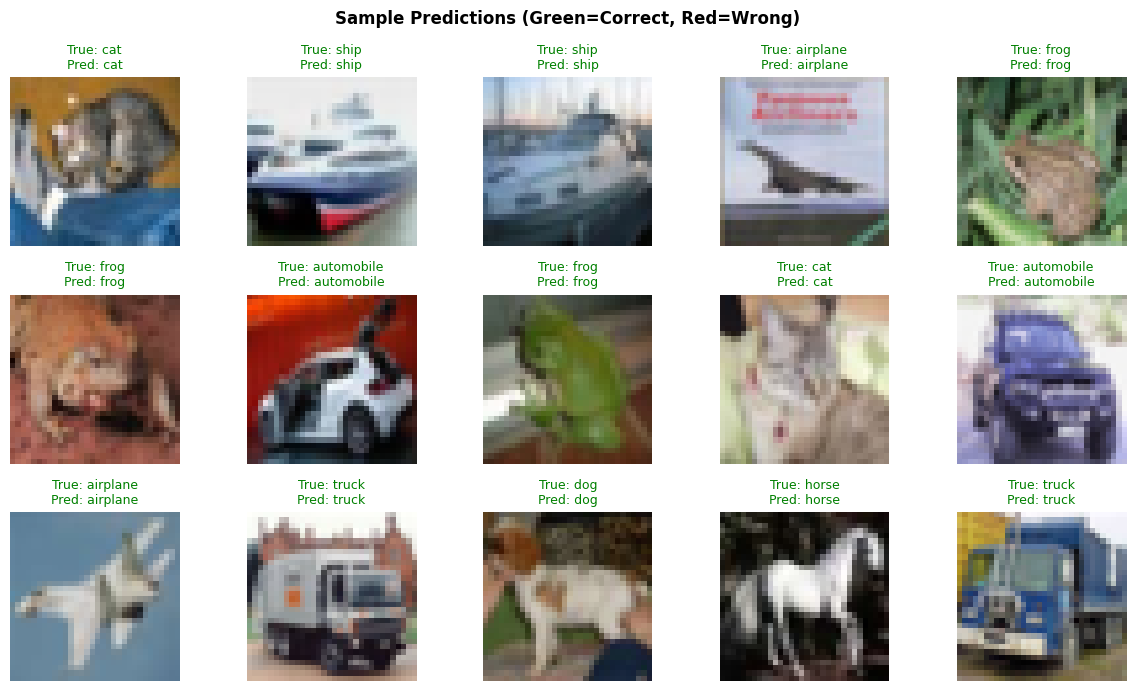

In [12]:
raw_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transforms.ToTensor())

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for i in range(15):
    img, true_label = raw_test[i]
    pred_label = all_preds[i]
    ax = axes[i//5][i%5]
    ax.imshow(img.permute(1,2,0))
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'True: {classes[true_label]}\nPred: {classes[pred_label]}', color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=100)
plt.show()

**Interpretation:** Green titles mean correct prediction, red means wrong. This gives a visual idea of where the model succeeds and fails.

## Step 12: Per-Class Accuracy

airplane    : 85.8%
automobile  : 88.5%
bird        : 75.5%
cat         : 69.7%
deer        : 75.2%
dog         : 70.3%
frog        : 83.9%
horse       : 86.0%
ship        : 89.4%
truck       : 88.8%


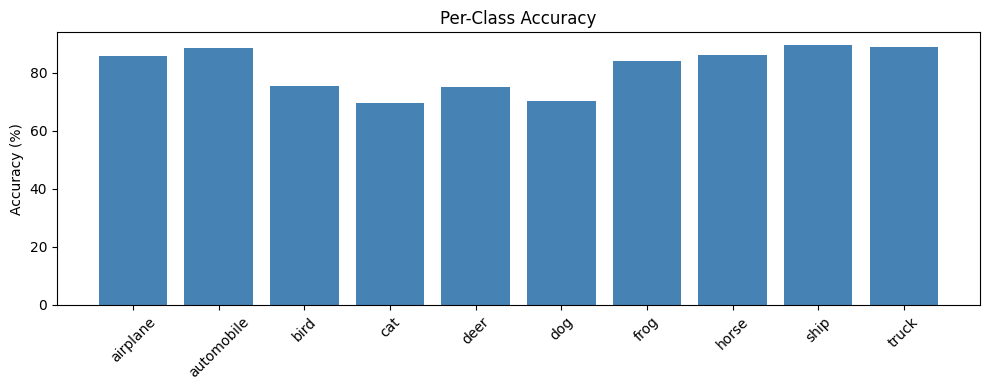

In [13]:
class_acc = []
for i in range(10):
    mask = all_labels == i
    acc = 100 * np.sum(all_preds[mask] == i) / np.sum(mask)
    class_acc.append(acc)
    print(f'{classes[i]:12s}: {acc:.1f}%')

plt.figure(figsize=(10, 4))
plt.bar(classes, class_acc, color='steelblue')
plt.ylabel('Accuracy (%)')
plt.title('Per-Class Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=100)
plt.show()

**Interpretation:** This confirms our previous metric analysis. The model achieves highest accuracy on `ship` (89.4%), `truck` (88.8%), and `automobile` (88.5%). It struggles most with `cat` (69.7%) and `dog` (70.3%), which are visually similar and often confused by the limited capacity of our SimpleCNN.

## Step 13: Save Model

In [14]:
torch.save(model.state_dict(), 'cnn_cifar10.pth')
print('Model saved as cnn_cifar10.pth')
print(f'Final Test Accuracy: {accuracy:.2f}%')

Model saved as cnn_cifar10.pth
Final Test Accuracy: 81.31%
